## Appendix: Explore Missing Values in Judicial Autonomy Dataset

In [2]:
import yaml

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
try:
    with open('../config.yaml') as file:
        config = yaml.safe_load(file)
except:
    print("Yaml file not found.")

### 1 Explore Missing Values in Raw Judicial Autonomy Dataset

In [6]:
# Load raw dataset q1
q1_df = pd.read_csv(config['input_data']['q1_dataset'])

# Display dataset
q1_df.head()

,username,country,country_code,question_no,uid,year,answer,value_na,value
0,ALB22uFF4m,Albania,ALB,1,q1c1_apjufc,2000,Mixed system [0.5],0.5,0.5
1,ALB22uFF4m,Albania,ALB,1,q1c1_apjufc,2001,Mixed system [0.5],0.5,0.5
2,ALB22uFF4m,Albania,ALB,1,q1c1_apjufc,2002,Mixed system [0.5],0.5,0.5
3,ALB22uFF4m,Albania,ALB,1,q1c1_apjufc,2003,Mixed system [0.5],0.5,0.5
4,ALB22uFF4m,Albania,ALB,1,q1c1_apjufc,2004,Mixed system [0.5],0.5,0.5


In [7]:
# Pivot long dataframe to wide dataframe
q1_pivoted = q1_df.pivot(index=['username', 'country', 'country_code', 'year'],
                         columns=['uid'],
                         values=['value'])

# Reset index and flattening multi-level column names
# Use lambda function to access tuple storing the multi-level column names
q1_pivoted.reset_index(inplace=True)
q1_pivoted.columns = [col[1] if col[1] else col[0] for col in q1_pivoted.columns]
q1_pivoted

,username,country,country_code,year,q1c1_apjuac,q1c1_apjufc,q1c1_apjuhc,q1c1_appealac,q1c1_appealfc,q1c1_appealhc,...,q1c4_casealloc,q1c4_competence,q1c4_manbudget,q1c4_reasondecis,q1c4_regbudget,q1c4_sameright,q1c4_subj,q1c4_whochair,q1c4_whocharge,q1c4_whoselect
0,ADMIN123,NaN,NaN,2000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ADMIN123,NaN,NaN,2001,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ADMIN123,NaN,NaN,2002,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ADMIN123,NaN,NaN,2003,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ADMIN123,NaN,NaN,2004,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099,UKR22Gf5Kx,Ukraine,UKR,2018,0.5,0.5,0.5,1.0,1.0,1.0,...,0.5,0.67,0.0,0.0,0.0,1.0,NaN,1.0,1.0,1.0
1100,UKR22Gf5Kx,Ukraine,UKR,2019,0.5,0.5,0.5,1.0,1.0,1.0,...,0.5,0.67,0.0,0.0,0.0,1.0,NaN,1.0,1.0,1.0
1101,UKR22Gf5Kx,Ukraine,UKR,2020,0.5,0.5,0.5,1.0,1.0,1.0,...,0.5,0.67,0.0,0.0,0.0,1.0,NaN,1.0,1.0,1.0
1102,UKR22Gf5Kx,Ukraine,UKR,2021,0.5,0.5,0.5,1.0,1.0,1.0,...,0.5,0.67,0.0,0.0,0.0,1.0,NaN,1.0,1.0,1.0


In [9]:
# Filter out countries / users
remove_usernames = ('ADMIN123', 'ALB22uFF4m','BEL22cEw8t', 'BIH22q2nOU', 'DNK22KFh1N', 'MNE22N8NJv', 'NLD22Ba53p', 'SRB22L4wbh')
q1_countries_cleaned = q1_pivoted[~q1_pivoted['username'].isin(remove_usernames)]
q1_countries_cleaned

,username,country,country_code,year,q1c1_apjuac,q1c1_apjufc,q1c1_apjuhc,q1c1_appealac,q1c1_appealfc,q1c1_appealhc,...,q1c4_casealloc,q1c4_competence,q1c4_manbudget,q1c4_reasondecis,q1c4_regbudget,q1c4_sameright,q1c4_subj,q1c4_whochair,q1c4_whocharge,q1c4_whoselect
46,ALB33wGG5n,Republic of Albania,ALA,2000,0.5,0.5,0.0,0.0,0.0,0.0,...,1.0,0.00,1.0,0.0,1.0,0.0,3.0,NaN,0.5,0.5
47,ALB33wGG5n,Republic of Albania,ALA,2001,0.5,0.5,0.0,0.0,0.0,0.0,...,1.0,0.00,1.0,0.0,1.0,0.0,3.0,NaN,0.5,0.5
48,ALB33wGG5n,Republic of Albania,ALA,2002,0.5,0.5,0.0,0.0,0.0,0.0,...,1.0,0.00,1.0,0.0,1.0,0.0,3.0,NaN,0.5,0.5
49,ALB33wGG5n,Republic of Albania,ALA,2003,0.5,0.5,0.0,0.0,0.0,0.0,...,1.0,0.00,1.0,0.0,1.0,0.0,3.0,NaN,0.5,0.5
50,ALB33wGG5n,Republic of Albania,ALA,2004,0.5,0.5,0.0,0.0,0.0,0.0,...,1.0,0.00,1.0,0.0,1.0,0.0,3.0,NaN,0.5,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099,UKR22Gf5Kx,Ukraine,UKR,2018,0.5,0.5,0.5,1.0,1.0,1.0,...,0.5,0.67,0.0,0.0,0.0,1.0,NaN,1.0,1.0,1.0
1100,UKR22Gf5Kx,Ukraine,UKR,2019,0.5,0.5,0.5,1.0,1.0,1.0,...,0.5,0.67,0.0,0.0,0.0,1.0,NaN,1.0,1.0,1.0
1101,UKR22Gf5Kx,Ukraine,UKR,2020,0.5,0.5,0.5,1.0,1.0,1.0,...,0.5,0.67,0.0,0.0,0.0,1.0,NaN,1.0,1.0,1.0
1102,UKR22Gf5Kx,Ukraine,UKR,2021,0.5,0.5,0.5,1.0,1.0,1.0,...,0.5,0.67,0.0,0.0,0.0,1.0,NaN,1.0,1.0,1.0


In [10]:
# Replace country names
q1_countries_cleaned.loc[:,'country'] = q1_countries_cleaned['country'].replace({
    "Czech Republic": "Czechia",
    "Republic of Albania": "Albania",
    "Republic of Serbia": "Serbia",
    "Bosnia and Herzegovina (BiH)": "Bosnia and Herzegovina",
    "Montenegro (MON)": "Montenegro",
    "Kingdom of Belgium": "Belgium"})
#q1_countries_cleaned

In [11]:
# Drop columns that contain '_subj' (i.e. subjective answers)
q1_subj_cleaned = q1_countries_cleaned.drop(list(q1_countries_cleaned.filter(regex='_subj')), axis=1)
q1_subj_cleaned

,username,country,country_code,year,q1c1_apjuac,q1c1_apjufc,q1c1_apjuhc,q1c1_appealac,q1c1_appealfc,q1c1_appealhc,...,q1c3_sanctscale,q1c4_casealloc,q1c4_competence,q1c4_manbudget,q1c4_reasondecis,q1c4_regbudget,q1c4_sameright,q1c4_whochair,q1c4_whocharge,q1c4_whoselect
46,ALB33wGG5n,Albania,ALA,2000,0.5,0.5,0.0,0.0,0.0,0.0,...,0.5,1.0,0.00,1.0,0.0,1.0,0.0,NaN,0.5,0.5
47,ALB33wGG5n,Albania,ALA,2001,0.5,0.5,0.0,0.0,0.0,0.0,...,0.5,1.0,0.00,1.0,0.0,1.0,0.0,NaN,0.5,0.5
48,ALB33wGG5n,Albania,ALA,2002,0.5,0.5,0.0,0.0,0.0,0.0,...,0.5,1.0,0.00,1.0,0.0,1.0,0.0,NaN,0.5,0.5
49,ALB33wGG5n,Albania,ALA,2003,0.5,0.5,0.0,0.0,0.0,0.0,...,0.5,1.0,0.00,1.0,0.0,1.0,0.0,NaN,0.5,0.5
50,ALB33wGG5n,Albania,ALA,2004,0.5,0.5,0.0,0.0,0.0,0.0,...,0.5,1.0,0.00,1.0,0.0,1.0,0.0,NaN,0.5,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099,UKR22Gf5Kx,Ukraine,UKR,2018,0.5,0.5,0.5,1.0,1.0,1.0,...,1.0,0.5,0.67,0.0,0.0,0.0,1.0,1.0,1.0,1.0
1100,UKR22Gf5Kx,Ukraine,UKR,2019,0.5,0.5,0.5,1.0,1.0,1.0,...,1.0,0.5,0.67,0.0,0.0,0.0,1.0,1.0,1.0,1.0
1101,UKR22Gf5Kx,Ukraine,UKR,2020,0.5,0.5,0.5,1.0,1.0,1.0,...,1.0,0.5,0.67,0.0,0.0,0.0,1.0,1.0,1.0,1.0
1102,UKR22Gf5Kx,Ukraine,UKR,2021,0.5,0.5,0.5,1.0,1.0,1.0,...,1.0,0.5,0.67,0.0,0.0,0.0,1.0,1.0,1.0,1.0


In [13]:
# Check for missing values across columns (in percentage) 
columns_nan_percentage = q1_subj_cleaned.isna().mean().sort_values(ascending=False)*100
columns_nan_percentage

q1c2_retireage       85.108696
q1c2_jubonus         51.195652
q1c3_immunlift       31.304348
q1c3_evalints        25.326087
q1c4_whochair        19.891304
q1c4_sameright        8.913043
q1c4_competence       6.086957
q1c4_reasondecis      6.086957
q1c1_exvetoac         4.456522
q1c4_whocharge        3.586957
q1c4_whoselect        3.369565
q1c4_casealloc        3.152174
q1c1_apjufc           2.500000
q1c1_appresidfc       2.500000
q1c4_manbudget        2.500000
q1c2_jutransf         2.500000
q1c3_initdiscip       2.282609
q1c2_termacju         1.956522
q1c1_appresidac       1.956522
q1c1_apjuac           1.956522
q1c1_appealac         1.956522
q1c1_critacints       1.956522
q1c1_critaclaw        1.956522
q1c1_appresidhc       0.217391
q1c1_transplaw        0.217391
q1c1_appealhc         0.000000
q1c2_juabsimmun       0.000000
q1c1_probju           0.000000
q1c1_exvetofc         0.000000
q1c1_exvetohc         0.000000
q1c1_crithclaw        0.000000
q1c1_critfcints       0.000000
q1c1_cri

In [14]:
# Decide to drop all questions with more than 20% values missing
columns_nan_20_percent = columns_nan_percentage[columns_nan_percentage > 20].index
columns_nan_20_percent

Index(['q1c2_retireage', 'q1c2_jubonus', 'q1c3_immunlift', 'q1c3_evalints'], dtype='object')

**Summary:**
- Columns with more than 20% missing values across all countries and years:
  - q1c2_retireage,
  - q1c2_jubonus,
  - q1c3_immunlift,
  - q1c3_evalints
- Remove those question items from dataset -- see cleaning function `cleaning_judicial_autonomy_data()`

### 2 Explore Missing Values in Clean Judicial Autonomy Dataset

In [15]:
# Load clean dataset
q1_cleaned = pd.read_csv(config['output_data']['q1_dataset'])

# Display dataset
q1_cleaned

,username,country,country_code,year,q1c1_apjuac,q1c1_apjufc,q1c1_apjuhc,q1c1_appealac,q1c1_appealfc,q1c1_appealhc,...,q1c3_sanctscale,q1c4_casealloc,q1c4_competence,q1c4_manbudget,q1c4_reasondecis,q1c4_regbudget,q1c4_sameright,q1c4_whochair,q1c4_whocharge,q1c4_whoselect
0,ALB33wGG5n,Albania,ALA,2000,0.5,0.5,0.0,0.0,0.0,0.0,...,0.5,1.0,0.00,1.0,0.0,1.0,0.0,NaN,0.5,0.5
1,ALB33wGG5n,Albania,ALA,2001,0.5,0.5,0.0,0.0,0.0,0.0,...,0.5,1.0,0.00,1.0,0.0,1.0,0.0,NaN,0.5,0.5
2,ALB33wGG5n,Albania,ALA,2002,0.5,0.5,0.0,0.0,0.0,0.0,...,0.5,1.0,0.00,1.0,0.0,1.0,0.0,NaN,0.5,0.5
3,ALB33wGG5n,Albania,ALA,2003,0.5,0.5,0.0,0.0,0.0,0.0,...,0.5,1.0,0.00,1.0,0.0,1.0,0.0,NaN,0.5,0.5
4,ALB33wGG5n,Albania,ALA,2004,0.5,0.5,0.0,0.0,0.0,0.0,...,0.5,1.0,0.00,1.0,0.0,1.0,0.0,NaN,0.5,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,UKR22Gf5Kx,Ukraine,UKR,2018,0.5,0.5,0.5,1.0,1.0,1.0,...,1.0,0.5,0.67,0.0,0.0,0.0,1.0,1.0,1.0,1.0
916,UKR22Gf5Kx,Ukraine,UKR,2019,0.5,0.5,0.5,1.0,1.0,1.0,...,1.0,0.5,0.67,0.0,0.0,0.0,1.0,1.0,1.0,1.0
917,UKR22Gf5Kx,Ukraine,UKR,2020,0.5,0.5,0.5,1.0,1.0,1.0,...,1.0,0.5,0.67,0.0,0.0,0.0,1.0,1.0,1.0,1.0
918,UKR22Gf5Kx,Ukraine,UKR,2021,0.5,0.5,0.5,1.0,1.0,1.0,...,1.0,0.5,0.67,0.0,0.0,0.0,1.0,1.0,1.0,1.0


In [25]:
# Check datatypes and missing values

q1_cleaned.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 54 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   username           920 non-null    object 
 1   country            920 non-null    object 
 2   country_code       920 non-null    object 
 3   year               920 non-null    int64  
 4   q1c1_apjuac        902 non-null    float64
 5   q1c1_apjufc        897 non-null    float64
 6   q1c1_apjuhc        920 non-null    float64
 7   q1c1_appealac      902 non-null    float64
 8   q1c1_appealfc      920 non-null    float64
 9   q1c1_appealhc      920 non-null    float64
 10  q1c1_appresidac    902 non-null    float64
 11  q1c1_appresidfc    897 non-null    float64
 12  q1c1_appresidhc    918 non-null    float64
 13  q1c1_critacints    902 non-null    float64
 14  q1c1_critaclaw     902 non-null    float64
 15  q1c1_critfcints    920 non-null    float64
 16  q1c1_critfclaw     920 non

In [16]:
# Check for missing values, sort by count

q1_cleaned.isna().sum().sort_values(ascending=False)

q1c4_whochair        183
q1c4_sameright        82
q1c4_reasondecis      56
q1c4_competence       56
q1c1_exvetoac         41
q1c4_whocharge        33
q1c4_whoselect        31
q1c4_casealloc        29
q1c2_jutransf         23
q1c1_apjufc           23
q1c1_appresidfc       23
q1c4_manbudget        23
q1c3_initdiscip       21
q1c2_termacju         18
q1c1_critaclaw        18
q1c1_critacints       18
q1c1_appealac         18
q1c1_apjuac           18
q1c1_appresidac       18
q1c1_transplaw         2
q1c1_appresidhc        2
country                0
q1c1_exvetohc          0
q1c1_exvetofc          0
q1c1_crithclaw         0
q1c1_crithcints        0
q1c1_critfcints        0
q1c1_critfclaw         0
q1c1_apjuhc            0
q1c1_appealfc          0
q1c1_appealhc          0
username               0
year                   0
country_code           0
q1c2_jufuncimmun       0
q1c2_jupension         0
q1c2_juremove          0
q1c2_juabsimmun        0
q1c3_discipints        0
q1c3_discipbody        0


In [17]:
# Summary

print(f"Number of columns items that contain at least one missing value: {q1_cleaned.isnull().any(axis = 0).sum()}")
print(f"Number of rows that contain at least one missing value: {q1_cleaned.isnull().any(axis = 1).sum()}")

Number of columns items that contain at least one missing value: 21
Number of rows that contain at least one missing value: 285


**Summary:**
- Distribution of missing values:
  - Question items with at least one missing value: 21
  - Country-years with at least one missing value: 285
- For the consistency and completeness of the data for each country case, rows and columns with missing values cannot be removed, but must be filled in in a meaningful and coherent way.

**Next step:**
- Understand the distribution of missing values across countries and years:
  - Are missing values clustered around a particular question item and country? -- This could be an indicator that the question item did not appear to the country expert to be applicable to the specific case.
  - Or do missing values spread across multiple country cases? -- This would suggest ambiguity in the question item itself.

### 3 Explore Missing Values Across Micro Indicator Subsets

#### 3.1 Identify missing values for each country case

In [18]:
# Count missing values for each country and question item
cols_with_nan = q1_cleaned.columns[q1_cleaned.isna().any()].tolist()
df_nan_counts = q1_cleaned.groupby('country')[cols_with_nan].apply(lambda x: x.isna().sum()).reset_index()

# Summing up NaN counts across all numeric columns for each row
numeric_cols = df_nan_counts.select_dtypes(exclude='object').columns

# Calculate the 'total_nan'
df_nan_counts['total_nan'] = df_nan_counts[numeric_cols].sum(axis=1)
df_nan_counts

# Sort countries by 'total_nan'
df_nan_counts_sorted = df_nan_counts.sort_values(by='total_nan', ascending=False)
df_nan_counts_sorted

# Move 'total_nan' to front position
move_column = df_nan_counts_sorted.pop('total_nan')
df_nan_counts_sorted.insert(1, 'total_nan', move_column)
df_nan_counts_sorted

,country,total_nan,q1c1_apjuac,q1c1_apjufc,q1c1_appealac,q1c1_appresidac,q1c1_appresidfc,q1c1_appresidhc,q1c1_critacints,q1c1_critaclaw,...,q1c2_termacju,q1c3_initdiscip,q1c4_casealloc,q1c4_competence,q1c4_manbudget,q1c4_reasondecis,q1c4_sameright,q1c4_whochair,q1c4_whocharge,q1c4_whoselect
17,Iceland,126,18,0,18,18,0,0,18,18,...,18,0,0,0,0,0,0,0,0,0
18,Ireland,114,0,0,0,0,0,0,0,0,...,0,0,0,19,0,19,19,19,19,19
14,Germany,94,0,0,0,0,0,2,0,0,...,0,21,0,0,23,0,23,23,0,0
9,Czechia,92,0,0,0,0,0,0,0,0,...,0,0,0,23,0,23,23,23,0,0
20,Latvia,60,0,0,0,0,0,0,0,0,...,0,0,0,10,0,10,10,10,10,10
36,Switzerland,46,0,23,0,0,23,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,Bosnia and Herzegovina,36,0,0,0,0,0,0,0,0,...,0,0,11,0,0,0,0,0,2,0
1,Armenia,26,0,0,0,0,0,0,0,0,...,0,0,18,0,0,0,0,8,0,0
0,Albania,23,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,23,0,0
6,Bulgaria,23,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,23,0,0


In [14]:
num_rows_nan = df_nan_counts_sorted[df_nan_counts_sorted['total_nan'] > 0].shape
num_rows_no_nan = df_nan_counts_sorted[df_nan_counts_sorted['total_nan'] == 0].shape

print(f"Number of countries with missing values: {num_rows[0]}")
print(f"Number of countries without missing values: {num_rows_no_nan[0]}")

Number of countries with missing values: 18
Number of countries without missing values: 22


In [17]:
# Display country cases with missing values only
df_countries_nan = df_nan_counts_sorted[df_nan_counts_sorted['total_nan'] > 0]
df_countries_nan

,country,total_nan,q1c1_apjuac,q1c1_apjufc,q1c1_appealac,q1c1_appresidac,q1c1_appresidfc,q1c1_appresidhc,q1c1_critacints,q1c1_critaclaw,...,q1c2_termacju,q1c3_initdiscip,q1c4_casealloc,q1c4_competence,q1c4_manbudget,q1c4_reasondecis,q1c4_sameright,q1c4_whochair,q1c4_whocharge,q1c4_whoselect
17,Iceland,126,18,0,18,18,0,0,18,18,...,18,0,0,0,0,0,0,0,0,0
18,Ireland,114,0,0,0,0,0,0,0,0,...,0,0,0,19,0,19,19,19,19,19
14,Germany,94,0,0,0,0,0,2,0,0,...,0,21,0,0,23,0,23,23,0,0
9,Czechia,92,0,0,0,0,0,0,0,0,...,0,0,0,23,0,23,23,23,0,0
20,Latvia,60,0,0,0,0,0,0,0,0,...,0,0,0,10,0,10,10,10,10,10
36,Switzerland,46,0,23,0,0,23,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,Bosnia and Herzegovina,36,0,0,0,0,0,0,0,0,...,0,0,11,0,0,0,0,0,2,0
1,Armenia,26,0,0,0,0,0,0,0,0,...,0,0,18,0,0,0,0,8,0,0
0,Albania,23,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,23,0,0
6,Bulgaria,23,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,23,0,0


**Summary:**
- Number of countries with missing values: 18
- Number of countries without missing values: 22
- Countries with most missing values:
  - Iceland
  - Ireland
  - Germany
  - Czechia
  - Latvia

#### 3.2 Identify missing values for specific question items

In [30]:
# Subset clean Judicial Autonomy Dataset for countries with missing values only
list_of_countries_nan = df_countries_nan['country']
q1_cleaned_nan = q1_cleaned[q1_cleaned['country'].isin(list_of_countries_nan)]
#q1_cleaned_nan

In [31]:
# Return rows with missing values for one specific question item (exammple)
q1c4_manbudget_nan = q1_cleaned_nan[q1_cleaned_nan['q1c4_manbudget'].isna()]
q1c4_manbudget_nan

,username,country,country_code,year,q1c1_apjuac,q1c1_apjufc,q1c1_apjuhc,q1c1_appealac,q1c1_appealfc,q1c1_appealhc,...,q1c3_sanctscale,q1c4_casealloc,q1c4_competence,q1c4_manbudget,q1c4_reasondecis,q1c4_regbudget,q1c4_sameright,q1c4_whochair,q1c4_whocharge,q1c4_whoselect
230,DEU22vd5fP,Germany,DEU,2000,1.0,1.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN,0.5,1.0
231,DEU22vd5fP,Germany,DEU,2001,1.0,1.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN,0.5,1.0
232,DEU22vd5fP,Germany,DEU,2002,1.0,1.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN,0.5,1.0
233,DEU22vd5fP,Germany,DEU,2003,1.0,1.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN,0.5,1.0
234,DEU22vd5fP,Germany,DEU,2004,1.0,1.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN,0.5,1.0
235,DEU22vd5fP,Germany,DEU,2005,1.0,1.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN,0.5,1.0
236,DEU22vd5fP,Germany,DEU,2006,1.0,1.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN,0.5,1.0
237,DEU22vd5fP,Germany,DEU,2007,1.0,1.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,NaN,1.0,0.0,NaN,NaN,0.5,1.0
238,DEU22vd5fP,Germany,DEU,2008,1.0,1.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN,0.5,1.0
239,DEU22vd5fP,Germany,DEU,2009,1.0,1.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN,0.5,1.0


**Summary:**
- Check missing values for each country and question items to understand the reason behind it
- Fill in the missing value with the closest value., i.e. use the median of the micro indicator subset -- see index building function `fill_na_per_micro_indicators()`

### 4 Compare Data Cleaning Strategies

#### 4.1. Prepare Data -- Fuzzy Data and Binary Data

In [4]:
# Import functions
import sys
sys.path.append('../py_files')

from functions import create_micro_indicators_dict, fill_na_per_micro_indicators, calculate_micro_indicators_mean

In [5]:
# Load clean dataset with fuzzy values
q1_cleaned = pd.read_csv(config['output_data']['q1_dataset'])

# Display dataset
q1_cleaned.head()

,username,country,country_code,year,q1c1_apjuac,q1c1_apjufc,q1c1_apjuhc,q1c1_appealac,q1c1_appealfc,q1c1_appealhc,...,q1c3_sanctscale,q1c4_casealloc,q1c4_competence,q1c4_manbudget,q1c4_reasondecis,q1c4_regbudget,q1c4_sameright,q1c4_whochair,q1c4_whocharge,q1c4_whoselect
0,ALB33wGG5n,Albania,ALA,2000,0.5,0.5,0.0,0.0,0.0,0.0,...,0.5,1.0,0.0,1.0,0.0,1.0,0.0,NaN,0.5,0.5
1,ALB33wGG5n,Albania,ALA,2001,0.5,0.5,0.0,0.0,0.0,0.0,...,0.5,1.0,0.0,1.0,0.0,1.0,0.0,NaN,0.5,0.5
2,ALB33wGG5n,Albania,ALA,2002,0.5,0.5,0.0,0.0,0.0,0.0,...,0.5,1.0,0.0,1.0,0.0,1.0,0.0,NaN,0.5,0.5
3,ALB33wGG5n,Albania,ALA,2003,0.5,0.5,0.0,0.0,0.0,0.0,...,0.5,1.0,0.0,1.0,0.0,1.0,0.0,NaN,0.5,0.5
4,ALB33wGG5n,Albania,ALA,2004,0.5,0.5,0.0,0.0,0.0,0.0,...,0.5,1.0,0.0,1.0,0.0,1.0,0.0,NaN,0.5,0.5


In [6]:
# Load clean dataset with binary values
q1_cleaned_binary = pd.read_csv(config['output_data']['q1_dataset_binary'])

# Display dataset
q1_cleaned_binary.head()

,username,country,country_code,year,q1c1_apjuac,q1c1_apjufc,q1c1_apjuhc,q1c1_appealac,q1c1_appealfc,q1c1_appealhc,...,q1c4_casealloc,q1c4_competence,q1c4_manbudget,q1c4_reasondecis,q1c4_regbudget,q1c4_sameright,q1c4_subj,q1c4_whochair,q1c4_whocharge,q1c4_whoselect
0,ALB33wGG5n,Albania,ALA,2000,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
1,ALB33wGG5n,Albania,ALA,2001,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
2,ALB33wGG5n,Albania,ALA,2002,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
3,ALB33wGG5n,Albania,ALA,2003,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,ALB33wGG5n,Albania,ALA,2004,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0


In [7]:
# Function to merge question items to create micro indicator subsets
created_micro_indicators = create_micro_indicators_dict(q1_cleaned)
created_micro_indicators_binary = create_micro_indicators_dict(q1_cleaned_binary)

In [8]:
# Function to fill in missing values in each micro indicator with row mode
filled_na_micro_indicators = fill_na_per_micro_indicators(created_micro_indicators)
filled_na_micro_indicators_binary = fill_na_per_micro_indicators(created_micro_indicators_binary)

In [9]:
# Function to calculate micro indicator measure by row-wise mean
calc_micro_indicators = calculate_micro_indicators_mean(filled_na_micro_indicators)
calc_micro_indicators_binary = calculate_micro_indicators_mean(filled_na_micro_indicators_binary)

In [10]:
# Plot distribution of micro indicator measures

def distribution_of_mean_values(subsets):
    
    # Set the grid size and the figure for subplots
    n_subsets = len(subsets)
    ncols = 5
    nrows = 3
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 3))
    fig.tight_layout(pad=3.0)  # spacing between plots

    # Set title of the plot
    #fig.suptitle('Distribution of Mean Values Across Micro Indicator Subsets', fontsize=16, y=1.025)

    # Flatten axes array for easy indexing, if necessary
    axs = axs.flatten() if n_subsets > 1 else [axs]

    # Create a histogram for each subset by dynamically selecting micro indicator measure 'q1_micro_...'
    for idx, (key, subset) in enumerate(subsets.items()):
        column_name = next((col for col in subset.columns if col.startswith("q1_micro")), None)
        sns.histplot(subset[column_name], bins=10, ax=axs[idx])
        axs[idx].set_title(f'{key}', fontsize=8)  # adjust subplot title
        axs[idx].set_xlabel('')  # remove x-axis label
        axs[idx].set_xticks(np.arange(start=0, stop=1.2, step=0.2))  # adjust ticks on x-axis

        ## Calculate and annotate mean and median
        mean_val = subset[column_name].mean().round(2)
        median_val = subset[column_name].median().round(2)

        # Adding lines for mean and median
        axs[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val}')
        axs[idx].axvline(median_val, color='blue', linestyle='-', label=f'Median: {median_val}')

        # Add legend
        axs[idx].legend(loc='upper left', fontsize=6)  # remove subplot legend


#### 4.2. Filling in missing values with row mode

#### 4.2.1 Distribution of Measures for each Micro Indicator -- Fuzzy Data

In [11]:
# Summary Statistics for Micro Indicator Measures After Filling in Missing Values (Fuzzy Data)

create_table = []

for key, item in calc_micro_indicators.items():
    for column in item.columns:
        if column.startswith('q1_micro'):
            mean = item[column].mean()
            median = item[column].median()
            
            create_table.append({'micro_indicator': key, 'mean': mean, 'median': median})
            
df_store_table = pd.DataFrame(create_table)
df_store_table.sort_values(by='mean', ascending=False)

,micro_indicator,mean,median
3,q1_micro_selection_predetermined_law,0.951793,1.00
8,q1_micro_judge_salary,0.939674,1.00
4,q1_micro_selection_intl_standards,0.829630,1.00
11,q1_micro_conflict_recusal_evaluation,0.808815,0.67
7,q1_micro_judge_immunity,0.750272,0.75
9,q1_micro_disciplinary_proceedings_law,0.746652,0.88
6,q1_micro_judge_tenure,0.734913,0.75
10,q1_micro_disciplinary_proceedings_actors,0.698804,0.75
12,q1_micro_judicial_self_governance_bodies,0.681359,0.67
13,q1_micro_judicial_self_governance_competences,0.653837,0.67


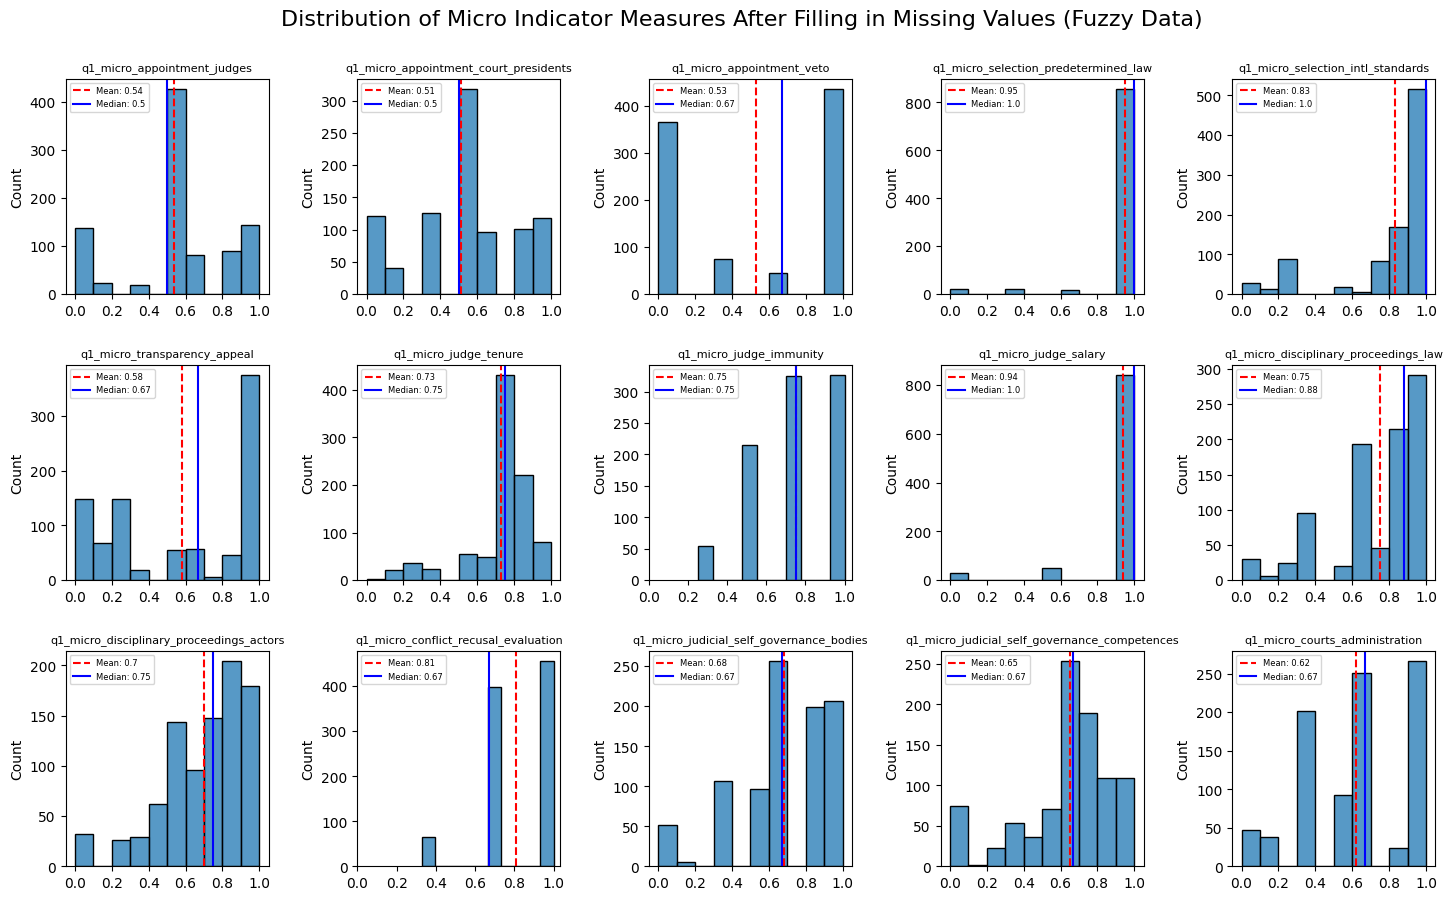

In [12]:
# Creating small multiples of histograms
distribution_of_mean_values(calc_micro_indicators)

fig = plt.gcf()
fig.suptitle('Distribution of Micro Indicator Measures After Filling in Missing Values (Fuzzy Data)', fontsize=16, y=1.025)

# Save and display plot
plt.savefig("../figures/small_multiples_histograms_micro_indicator_measures_fuzzy.jpeg", format="jpeg", dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show();

#### 4.2.2 Distribution of Measures for each Micro Indicator -- Binary Data

In [13]:
# Summary Statistics for Micro Indicator Measures After Filling in Missing Values (Fuzzy Data)

create_table = []

for key, item in calc_micro_indicators_binary.items():
    for column in item.columns:
        if column.startswith('q1_micro'):
            mean = item[column].mean()
            median = item[column].median()
            
            create_table.append({'micro_indicator': key, 'mean': mean, 'median': median})
            
df_store_table = pd.DataFrame(create_table)
df_store_table.sort_values(by='mean', ascending=False)

,micro_indicator,mean,median
3,q1_micro_selection_predetermined_law,0.951793,1.00
8,q1_micro_judge_salary,0.939674,1.00
11,q1_micro_conflict_recusal_evaluation,0.808815,0.67
4,q1_micro_selection_intl_standards,0.803533,1.00
7,q1_micro_judge_immunity,0.750272,0.75
13,q1_micro_judicial_self_governance_competences,0.711576,0.67
10,q1_micro_disciplinary_proceedings_actors,0.703804,0.75
6,q1_micro_judge_tenure,0.691304,0.75
9,q1_micro_disciplinary_proceedings_law,0.676902,0.75
14,q1_micro_courts_administration,0.599283,0.67


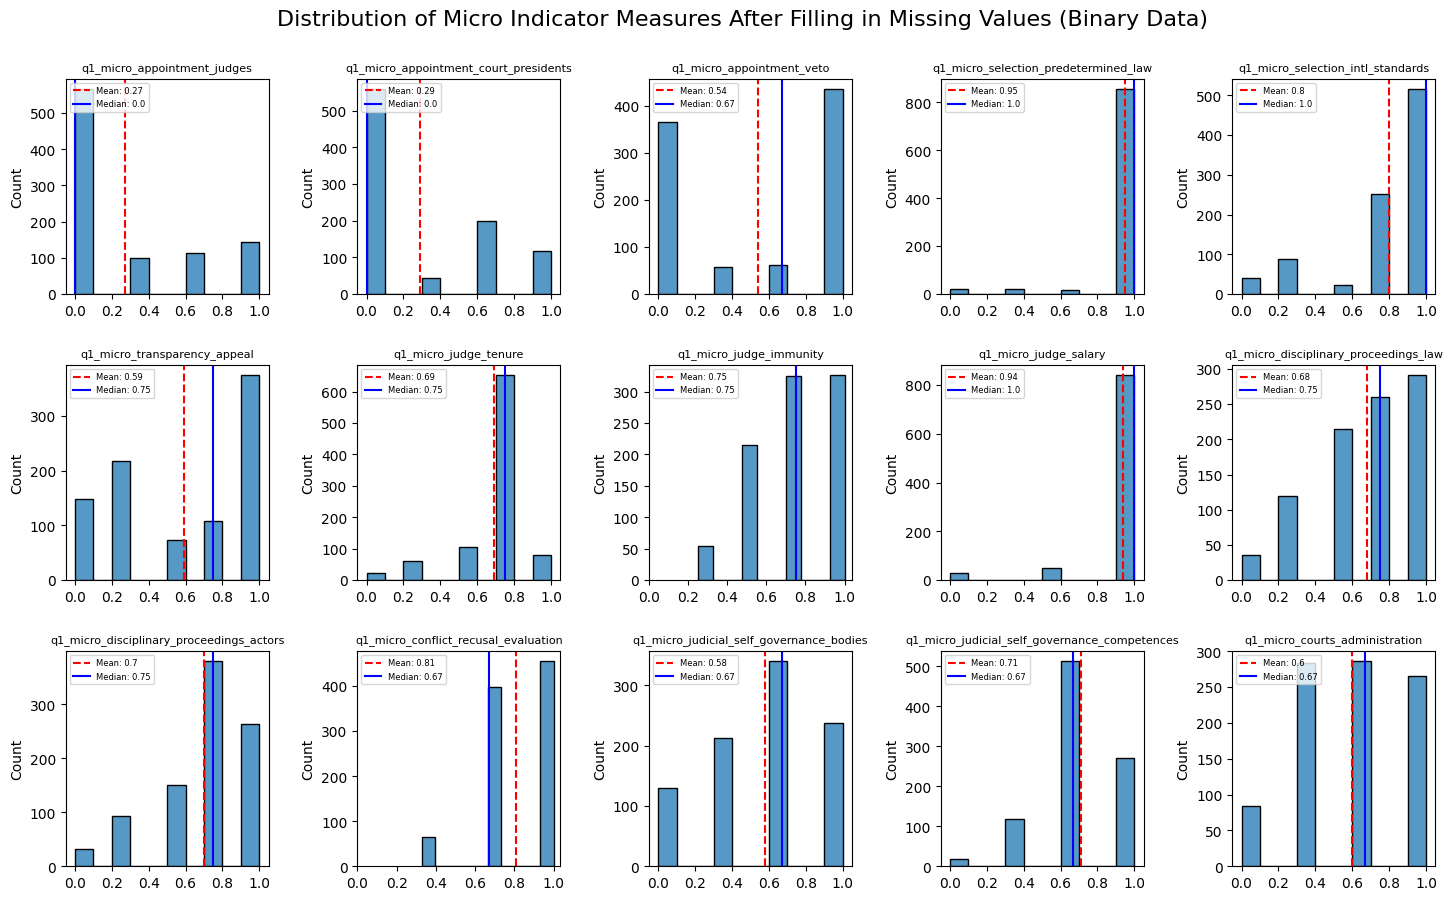

In [14]:
# Creating small multiples of histograms
distribution_of_mean_values(calc_micro_indicators_binary)

fig = plt.gcf()
fig.suptitle('Distribution of Micro Indicator Measures After Filling in Missing Values (Binary Data)', fontsize=16, y=1.025)

# Save and display plot
plt.savefig("../figures/small_multiples_histograms_micro_indicator_measures_binary.jpeg", format="jpeg", dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show();

**Summary:**
- Micro indicators with highest mean and median:
  - q1_micro_selection_predetermined_law
  - q1_micro_judge_salary
- Micro indicators with lowest mean and median:
  - q1_micro_appointment_veto
  - q1_micro_appointment_court_presidents
  - q1_micro_appointment_judges
    <br/>
    <br/>
- Recoding the dataset into binary values (i.e. 0.0 if value <= 0.5 and 1.0 if value > 0.5) results in a shift towards lower values in the overall dataset. This may be a practical approach to dealing with skewness in the data.
- However, as the small multiple histograms show, it also simplifies the range of values by shifting values to the edges (i.e. towards 0 and 1), potentially reducing the diversity within the value distribution and thus omitting more subtle patterns within the dataset. 

#### 4.3 Keeping Missing Values

#### 4.3.1 Distribution of Measures for each Micro Indicator -- Fuzzy Data

In [15]:
# Summary Statistics for Micro Indicator Measures After Filling in Missing Values (Fuzzy Data)

create_table = []

for key, item in created_micro_indicators.items():
    float_columns = item.select_dtypes(include='float')
    mean = float_columns.mean().mean()
    median = float_columns.median().mean()

    create_table.append({'micro_indicator': key, 'mean': mean, 'median': median})
            
df_store_table = pd.DataFrame(create_table)
df_store_table.sort_values(by='mean', ascending=False)


,micro_indicator,mean,median
3,q1_micro_selection_predetermined_law,0.951421,1.000000
8,q1_micro_judge_salary,0.939674,1.000000
4,q1_micro_selection_intl_standards,0.828018,1.000000
11,q1_micro_conflict_recusal_evaluation,0.807609,1.000000
7,q1_micro_judge_immunity,0.749018,1.000000
9,q1_micro_disciplinary_proceedings_law,0.746060,0.875000
6,q1_micro_judge_tenure,0.733512,0.750000
12,q1_micro_judicial_self_governance_bodies,0.724139,0.833333
10,q1_micro_disciplinary_proceedings_actors,0.702149,0.750000
13,q1_micro_judicial_self_governance_competences,0.693221,0.776667


#### 4.3.2 Distribution of Measures for each Micro Indicator -- Binary Data

In [16]:
# Summary Statistics for Micro Indicator Measures After Filling in Missing Values (Fuzzy Data)

create_table = []

for key, item in created_micro_indicators_binary.items():
    float_columns = item.select_dtypes(include='float')
    mean = float_columns.mean().mean()
    median = float_columns.median().mean()

    create_table.append({'micro_indicator': key, 'mean': mean, 'median': median})
            
df_store_table = pd.DataFrame(create_table)
df_store_table.sort_values(by='mean', ascending=False)


,micro_indicator,mean,median
3,q1_micro_selection_predetermined_law,0.951812,1.000000
8,q1_micro_judge_salary,0.939674,1.000000
11,q1_micro_conflict_recusal_evaluation,0.807609,1.000000
4,q1_micro_selection_intl_standards,0.803533,1.000000
7,q1_micro_judge_immunity,0.750272,1.000000
13,q1_micro_judicial_self_governance_competences,0.710145,0.666667
10,q1_micro_disciplinary_proceedings_actors,0.703804,0.750000
6,q1_micro_judge_tenure,0.691304,0.750000
9,q1_micro_disciplinary_proceedings_law,0.676902,0.750000
14,q1_micro_courts_administration,0.599275,1.000000


**Summary**
- The tables above show only minor deviations for both fuzzy and binary values when comparing datasets with missing values with datasets without missing values.
- This finding suggests that filling in missing data with the micro indicator median is a valid and robust strategy to achieve data consistency. 